# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fayrouzhassan2000/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [87]:
# Data loading

import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,
        AVG(gsc_avg_position) AS gsc_avg_position,
        SUM(ga4_sessions) AS ga4_sessions
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

from datasets import load_dataset

content_ds = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_content",
    split="train"
)

content_df = content_ds.to_pandas()

content_df = content_df[
    [
        "client_hash_id",
        "content_hash_id",
        "content_type"
    ]
]

feature_df = features.merge(
    content_df,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-04'
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

march = feature_df.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

march["is_declining_label"] = (
    march["april_impressions"] < march["gsc_impressions"]
)


march.drop(columns=["april_impressions"], axis = 1, inplace=True)

df = march.copy()
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,content_type,is_declining_label
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,4.394234,0.0,keyword article,False
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,2.714744,0.0,keyword article,False
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,6.481453,4.0,keyword article,True
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,6.320337,9.0,keyword article,False
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0,16.0,4.459107,3.0,keyword article,False


In [88]:
df[[
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions"
]].isna().sum()

,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,154699
ga4_sessions,70700


In [89]:
df[[
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions"
]].isna().mean() * 100

,0
gsc_impressions,0.000000
gsc_clicks,0.000000
gsc_avg_position,46.675235
ga4_sessions,21.331354


In [90]:
import pandas as pd
pd.crosstab(
    df["gsc_avg_position"].isna(),
    df["gsc_impressions"] == 0
)

gsc_impressions,False,True
gsc_avg_position,,
False,176738,0
True,0,154699


In [91]:
from datasets import load_dataset

clients_ds = load_dataset(
    "FlyRank/internship-warehouse",
    "dim_clients",
    split="train"
)

clients = clients_ds.to_pandas()

print(clients.shape)
print(clients.columns.tolist())
clients.head()

(104, 9)
['client_hash_id', 'is_active', 'has_gsc_access', 'has_ga4_access', 'access_profile', 'client_created_date', 'client_updated_date', 'gsc_data_start', 'ga4_data_start']


,client_hash_id,is_active,has_gsc_access,has_ga4_access,access_profile,client_created_date,client_updated_date,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,True,True,True,gsc_and_ga4,2026-04-15,2026-06-27,None,2026-05-22
1,client_05475c07ed21a83a,True,False,False,no_search_or_analytics_access,2026-04-01,2026-06-27,None,None
2,client_06d356715a8ff3b6,True,True,True,gsc_and_ga4,2026-03-23,2026-07-05,2026-04-10,2026-04-06
3,client_0797ff3a1fc9a6a5,True,False,False,no_search_or_analytics_access,2025-05-26,2026-06-27,2025-11-05,None
4,client_08a6a72ff48e62c0,True,True,False,gsc_only,2025-05-26,2026-06-27,2025-09-24,None


In [92]:
clients = clients[[
    "client_hash_id",
    "has_gsc_access",
    "has_ga4_access",
    "access_profile",
    "client_created_date",
    "client_updated_date",
    "gsc_data_start",
    "ga4_data_start"
]]

clients.head()

,client_hash_id,has_gsc_access,has_ga4_access,access_profile,client_created_date,client_updated_date,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,True,True,gsc_and_ga4,2026-04-15,2026-06-27,None,2026-05-22
1,client_05475c07ed21a83a,False,False,no_search_or_analytics_access,2026-04-01,2026-06-27,None,None
2,client_06d356715a8ff3b6,True,True,gsc_and_ga4,2026-03-23,2026-07-05,2026-04-10,2026-04-06
3,client_0797ff3a1fc9a6a5,False,False,no_search_or_analytics_access,2025-05-26,2026-06-27,2025-11-05,None
4,client_08a6a72ff48e62c0,True,False,gsc_only,2025-05-26,2026-06-27,2025-09-24,None


In [93]:
reason = features.merge(
    clients,
    on="client_hash_id",
    how="left"
)

In [94]:
reason

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,has_gsc_access,has_ga4_access,access_profile,client_created_date,client_updated_date,gsc_data_start,ga4_data_start
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,4.394234,0.0,True,True,gsc_and_ga4,2025-05-26,2026-06-27,2025-02-11,2026-03-24
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,2.714744,0.0,True,True,gsc_and_ga4,2025-05-26,2026-06-27,2025-02-11,2026-03-24
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,6.481453,4.0,True,True,gsc_and_ga4,2025-05-26,2026-06-27,2025-02-11,2026-03-24
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,6.320337,9.0,True,True,gsc_and_ga4,2025-05-26,2026-06-27,2025-02-11,2026-03-24
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0,16.0,4.459107,3.0,True,True,gsc_and_ga4,2025-05-26,2026-06-27,2025-02-11,2026-03-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
331432,client_4a18d1793d92fb84,content_abf5ac354a52662e,0.0,0.0,NaN,0.0,True,True,gsc_and_ga4,2025-06-24,2026-06-27,2025-09-24,2026-02-19
331433,client_4a18d1793d92fb84,content_15246f36b972664d,0.0,0.0,NaN,0.0,True,True,gsc_and_ga4,2025-06-24,2026-06-27,2025-09-24,2026-02-19
331434,client_4a18d1793d92fb84,content_8c18515477602726,0.0,0.0,NaN,0.0,True,True,gsc_and_ga4,2025-06-24,2026-06-27,2025-09-24,2026-02-19
331435,client_86ebc2f12c01f586,content_ead101e5a093ec80,0.0,0.0,NaN,0.0,True,True,gsc_and_ga4,2026-02-11,2026-06-27,2026-03-11,2026-03-10


In [95]:
pd.crosstab(
    df["ga4_sessions"].isna(),
    reason["has_ga4_access"]
)

has_ga4_access,False,True
ga4_sessions,,
False,0,260616
True,70700,0


In [96]:
# =========================
# Handling Missing Values
# =========================

# 1. GA4 Sessions
# NaN means the client has no GA4 access
df["ga4_sessions"] = df["ga4_sessions"].fillna(0)


# 2. GSC Average Position
# NaN means there were no GSC impressions
# Create an indicator before imputation
df["gsc_avg_position_missing"] = (
    df["gsc_avg_position"].isna().astype(int)
)

# Impute missing positions with the median
gsc_position_median = df["gsc_avg_position"].median()

df["gsc_avg_position"] = df["gsc_avg_position"].fillna(
    gsc_position_median
)


# Check
print("Missing values after handling:")
print(
    df[
        [
            "gsc_avg_position",
            "gsc_avg_position_missing",
            "ga4_sessions"
        ]
    ].isna().sum()
)

Missing values after handling:
gsc_avg_position            0
gsc_avg_position_missing    0
ga4_sessions                0
dtype: int64


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## 1. Method Choice and Why

I chose **Random Forest** as the main machine learning method for this task because the target variable `is_declining_label` is binary, making this a classification problem.

Random Forest is suitable because it can capture **non-linear relationships and interactions** between content performance features such as GSC impressions, clicks, average position, GA4 sessions, and content type. It also does not require strong assumptions about the relationship between the features and the target.

The model will be evaluated against the **Week-4 baseline** using the same test split and the same classification metrics. The goal is not to use a more complex model simply because it is more complex, but to determine whether Random Forest provides a meaningful improvement over the simple baseline.


In [97]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

I will use a grouped train/test split by `client_hash_id`, so all pages belonging to the same client stay in either the training set or the test set. This avoids having pages from the same client in both sets and makes the evaluation more honest.

The prediction is also time-aware in the problem definition: March performance is used as the feature window and April performance is used to define the decline label. Since the modeling dataset represents this single March-to-April prediction window, I will not create an artificial time split across months.

This split is appropriate because the goal is to evaluate whether the model can generalize to content from clients it did not see during training.

In [98]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.model_selection import GroupShuffleSplit

# Define features and target
X = df.drop(columns=["is_declining_label"])
y = df["is_declining_label"]

# Use client as the grouping variable
groups = df["client_hash_id"]

# Create grouped train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (300880, 8)
Test shape: (30557, 8)


In [99]:
# Check that no client appears in both train and test
train_clients = set(df.iloc[train_idx]["client_hash_id"])
test_clients = set(df.iloc[test_idx]["client_hash_id"])

overlap = train_clients.intersection(test_clients)

print("Number of overlapping clients:", len(overlap))

Number of overlapping clients: 0


In [100]:
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Train target distribution:
is_declining_label
False    0.661433
True     0.338567
Name: proportion, dtype: float64

Test target distribution:
is_declining_label
False    0.669503
True     0.330497
Name: proportion, dtype: float64


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [101]:
df.isnull().sum()

,0
client_hash_id,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,0
ga4_sessions,0
content_type,0
is_declining_label,0
gsc_avg_position_missing,0


In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "content_type",
    "gsc_avg_position_missing"
]

X = df[feature_cols]
y = df["is_declining_label"]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

numeric_features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "gsc_avg_position_missing"
]

categorical_features = [
    "content_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


In [103]:
baseline_pred = (
    X_test["gsc_impressions"] > 100
)

In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics

comp = pd.DataFrame({"ML Model":{"Accuracy":accuracy_score(y_test, y_pred), "Precision":precision_score(y_test, y_pred), "Recall":recall_score(y_test, y_pred), "F1 Score":f1_score(y_test, y_pred)},
             "BaseLine":{"Accuracy":accuracy_score(y_test, baseline_pred), "Precision":precision_score(y_test, baseline_pred), "Recall":recall_score(y_test, baseline_pred), "F1 Score":f1_score(y_test, baseline_pred)}})
comp

,ML Model,BaseLine
Accuracy,0.771051,0.738521
Precision,0.621810,0.600630
Recall,0.784236,0.623230
F1 Score,0.693642,0.611721


In [105]:
import numpy as np

K = 20

# Probability of class 1 (declining)
rf_scores = rf_pipeline.predict_proba(X_test)[:, 1]

# Rank by highest declining probability
top_k_idx = np.argsort(rf_scores)[::-1][:K]

# Precision@K
precision_at_k_rf = y_test.iloc[top_k_idx].mean()

print(f"Random Forest Precision@{K}: {precision_at_k_rf:.3f}")

Random Forest Precision@20: 0.650


In [106]:
baseline_pred = (
    X_test["gsc_impressions"] > 100
).astype(int)

In [107]:
baseline_scores = X_test["gsc_impressions"].values

baseline_top_k_idx = np.argsort(baseline_scores)[::-1][:K]

precision_at_k_baseline = y_test.iloc[baseline_top_k_idx].mean()

print(f"Baseline Precision@{K}: {precision_at_k_baseline:.3f}")

Baseline Precision@20: 0.550


In [108]:
print("Random Forest :", precision_at_k_rf)
print("Baseline      :", precision_at_k_baseline)

Random Forest : 0.65
Baseline      : 0.55


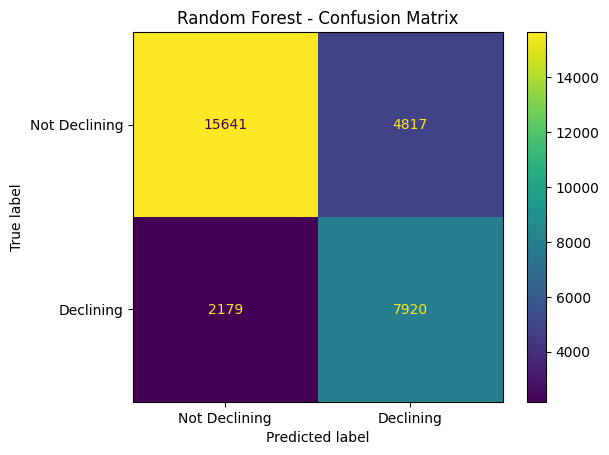

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Declining", "Declining"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [110]:
model = rf_pipeline.named_steps["model"]
preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,num__gsc_avg_position,0.390733
0,num__gsc_impressions,0.339556
4,num__gsc_avg_position_missing,0.169381
1,num__gsc_clicks,0.053992
3,num__ga4_sessions,0.038165
6,cat__content_type_feedly article,0.004240
7,cat__content_type_keyword article,0.003575
5,cat__content_type_comparison article,0.000358


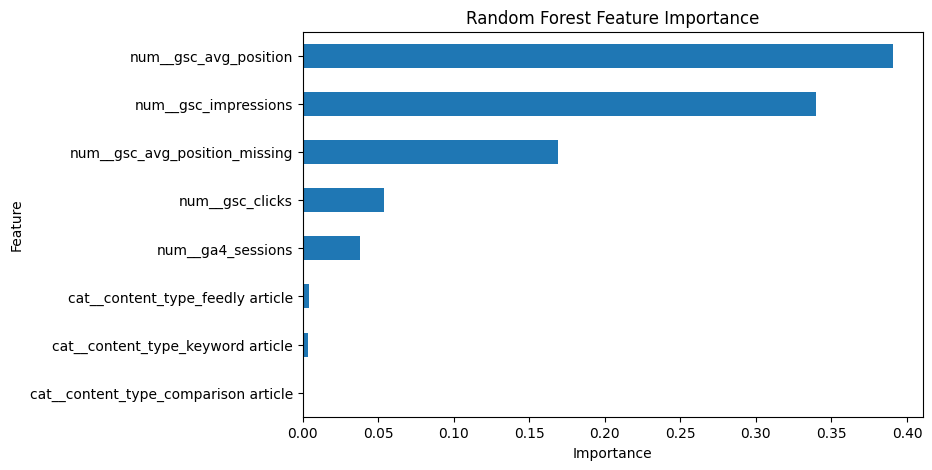

In [111]:
feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [112]:
print(rf_pipeline.named_steps["preprocessor"])

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['gsc_impressions', 'gsc_clicks',
                                  'gsc_avg_position', 'ga4_sessions',
                                  'gsc_avg_position_missing']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['content_type'])])


In [113]:
print(rf_pipeline.named_steps["preprocessor"])

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['gsc_impressions', 'gsc_clicks',
                                  'gsc_avg_position', 'ga4_sessions',
                                  'gsc_avg_position_missing']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['content_type'])])


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [115]:
# Error analysis
error_df = X_test.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = y_pred

# False positives: predicted declining, but actually not declining
false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

# False negatives: actually declining, but model missed it
false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 4817
False Negatives: 2179


In [116]:
false_positives.describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,gsc_avg_position_missing
count,4817.000000,4817.000000,4817.000000,4817.000000,4817.0
mean,1539.543492,4.395890,14.981346,4.105667,0.0
std,9963.323975,83.168858,14.210014,41.724464,0.0
min,1.000000,0.000000,0.000000,0.000000,0.0
25%,27.000000,0.000000,5.666667,0.000000,0.0
50%,287.000000,0.000000,9.163756,1.000000,0.0
75%,1173.000000,2.000000,19.499708,3.000000,0.0
max,617124.000000,5668.000000,95.000000,2730.000000,0.0


In [121]:
false_negatives.describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,gsc_avg_position_missing
count,2179.000000,2179.000000,2179.000000,2179.000000,2179.0
mean,1980.914181,9.109683,13.672593,8.195961,0.0
std,6832.984055,35.588163,13.428837,32.263360,0.0
min,1.000000,0.000000,0.000000,0.000000,0.0
25%,16.000000,0.000000,4.980854,0.000000,0.0
50%,260.000000,0.000000,8.144752,1.000000,0.0
75%,1535.500000,4.000000,17.822598,4.000000,0.0
max,203497.000000,703.000000,98.000000,684.000000,0.0


In [120]:
feature_importance.head(10)

,Feature,Importance
2,num__gsc_avg_position,0.390733
0,num__gsc_impressions,0.339556
4,num__gsc_avg_position_missing,0.169381
1,num__gsc_clicks,0.053992
3,num__ga4_sessions,0.038165
6,cat__content_type_feedly article,0.004240
7,cat__content_type_keyword article,0.003575
5,cat__content_type_comparison article,0.000358


### Error Analysis

The model produces both false positives and false negatives, with more false negatives than false positives. False negatives tend to have lower GSC impressions, clicks, and GA4 sessions, suggesting that low-traffic content is harder for the model to identify as declining.

The feature importance results show that the model relies mainly on `gsc_avg_position`, `gsc_impressions`, and `gsc_avg_position_missing`. In contrast, `content_type` contributes very little to the prediction. This suggests that the model is primarily driven by search-performance signals rather than the type of content.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.